In [2]:
from sklearn.datasets import make_blobs

In [3]:
raw_data = make_blobs(n_samples = 200, n_features = 2, centers = 3, cluster_std = 1.5)
print(raw_data)

(array([[ -8.89206279,   4.94187311],
       [ -9.94483477,   6.34481116],
       [-11.54370408,   4.27792824],
       [-13.88361946,   3.23453852],
       [ -7.93097791,   2.01448632],
       [ -7.14203723,   3.81788001],
       [ -9.33844686,   5.26758102],
       [ -6.93719064,  -7.33313881],
       [ -8.17061791,  -6.42184125],
       [ -6.22259066,   5.78899509],
       [ -9.20317631,   8.61766726],
       [ -9.60054499,  -7.65041335],
       [ -9.79602666,  -7.27853047],
       [-11.87381894,   6.33744176],
       [ -7.07405142,   5.50737167],
       [ -7.46576218,  -8.82544578],
       [ -9.21712651,   5.29106758],
       [ -8.66902676,   7.82290107],
       [ -8.25939519,   6.18604586],
       [ -8.39468435,  -6.26066688],
       [ -8.89367482, -10.15894932],
       [ -9.72869764,  -5.26440262],
       [-10.3098387 ,  -6.68077037],
       [-11.8742125 ,   3.3041457 ],
       [-10.11528414,   3.69789396],
       [-10.97910793,   7.76321531],
       [ -9.05324324,   7.59969037],


In [4]:
import pandas as pd
import numpy as np
import seaborn
import matplotlib.pyplot as plt

In [6]:
from sklearn.cluster import KMeans

In [7]:
model = KMeans(n_clusters=3)

In [8]:
model.fit(raw_data[0])

KMeans(n_clusters=3)

In [9]:
model.labels_

array([1, 0, 2, 1, 0, 0, 1, 0, 0, 1, 0, 2, 0, 2, 0, 0, 0, 1, 0, 1, 0, 2,
       2, 1, 0, 0, 2, 1, 1, 0, 1, 0, 1, 1, 0, 1, 2, 2, 2, 1, 1, 1, 2, 0,
       2, 0, 0, 1, 1, 2, 0, 1, 2, 1, 0, 2, 0, 2, 1, 1, 0, 2, 0, 1, 2, 1,
       0, 1, 1, 1, 2, 1, 0, 1, 1, 1, 1, 2, 1, 2, 0, 1, 0, 2, 0, 0, 0, 2,
       1, 1, 0, 1, 2, 0, 2, 2, 1, 0, 0, 1, 2, 0, 2, 2, 0, 1, 1, 0, 2, 2,
       0, 1, 1, 1, 2, 2, 0, 2, 0, 2, 0, 0, 0, 1, 1, 2, 1, 2, 1, 2, 2, 2,
       2, 1, 0, 2, 0, 1, 2, 2, 2, 0, 0, 1, 2, 2, 2, 0, 0, 2, 1, 1, 0, 1,
       2, 0, 0, 2, 2, 2, 1, 2, 1, 2, 0, 1, 0, 1, 0, 2, 2, 1, 1, 2, 2, 1,
       0, 1, 2, 1, 1, 2, 0, 2, 2, 1, 0, 0, 1, 2, 0, 1, 2, 0, 2, 0, 0, 0,
       0, 0], dtype=int32)

In [10]:
model.cluster_centers_

array([[ 3.58984062, -3.38095861],
       [ 6.62267709,  2.96431528],
       [ 7.51196482, -5.50831532]])

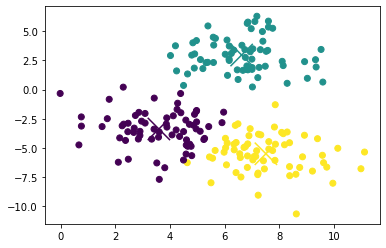

In [11]:
plt.scatter(raw_data[0][:,0], raw_data[0][:,1], c=model.labels_)
plt.scatter(model.cluster_centers_[:,0], model.cluster_centers_[:,1], c=[0,1,2], marker='x', s=[500, 500, 500])

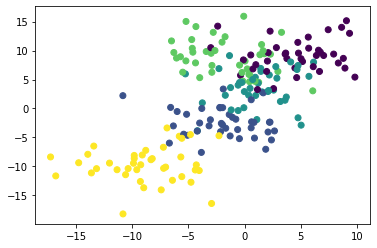

In [12]:
raw_data = make_blobs(n_samples = 200, n_features = 2, centers = 5, cluster_std = 3)
plt.scatter(raw_data[0][:,0], raw_data[0][:,1], c=raw_data[1])

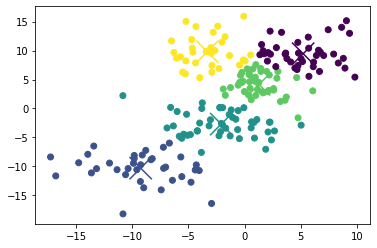

In [13]:
# generate an instance of the model with five clusters and fit to our existing data
model = KMeans(n_clusters=5)
model.fit(raw_data[0])

# scatter plot with the Kmeans generated cluster labels and overlay x's for the cluster centroids.
plt.scatter(raw_data[0][:,0], raw_data[0][:,1], c=model.labels_)
plt.scatter(model.cluster_centers_[:,0], model.cluster_centers_[:,1], c=[0,1,2,3,4], marker='x', s=[500, 500, 500, 500, 500])

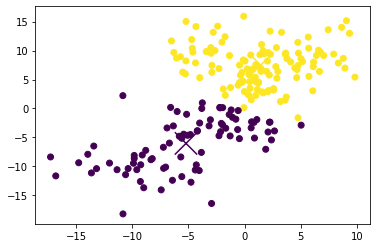

In [14]:
# generate an instance of the model with five clusters and fit to our existing data
model = KMeans(n_clusters=2)
model.fit(raw_data[0])

# scatter plot with the Kmeans generated cluster labels and overlay x's for the cluster centroids.
plt.scatter(raw_data[0][:,0], raw_data[0][:,1], c=model.labels_)
plt.scatter(model.cluster_centers_[:,0], model.cluster_centers_[:,1], c=[0,1], marker='x', s=[500, 500])

### Methods for determining Kmeans goodness-of-fit
The Elbow Method is the most popular for determine the optimal number of clusters. This method leverages a quantity called the Within-Cluster-Sum of Squared Errors (WSS) or inertia for different number of clusters $K$ and choosing the $K$ for which the WSS diminishes significantly. The formula for the WSS can be written
$$
WSS = \sum_{k=1}^K \sum_{j \in S_k} || x_j - \mu_k ||^2,
$$
where $S_k$ is the set of data points in the $k$th cluster and recall $\mu_k$ is the centroid of the $k$th cluster. The amount of variance in the data explained increases rapidly for a small number of clusters but such gains fall off as more clusters are used and this should be apparent in a curve representing either variance explained or error in grouping. The elbow is the point where this transition occurs. Admittedly, I find this method to be intuitive but a bit vague, since it's not always precisely apparent where exactly the elbow is. We'll illustrate this below.

Fortunately, python has this quantity, inertia, readily computed for us. Let's see what it is for our previous application of Kmeans to the five blob synthetic data set.

In [15]:
model.inertia_

6771.79873017349

OK. We can recover this number, but it does not have much meaning out of context. The only thing we really know is that smaller numbers represent a good account of variance in the data and larger numbers represent a poor account. Remember, we said this number was useful comparitively across different cluster counts $K$. In this sense $K$ can be considered a hyperparameter and the inertia (or WSS) is an objective function which we will calculate to determine the best choice of the hyperparameter. This means, we must try a number of $K$ values and then plot the inertia for each. The curve that's traced out should have some visible elbow and the $K$ value at this elbow will be our best choice. We'll also make a separate list of just the inertias to plot.

Text(0, 0.5, 'intertia (or WSS)')

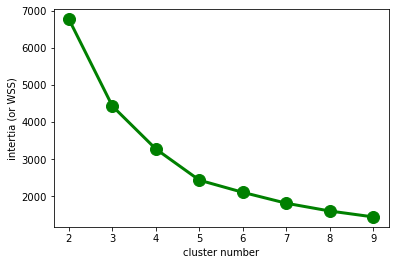

In [16]:
# lets make a list of models we'll append to
model_list = []
inertia_list = []
for j in range(2,10):
    model = KMeans(n_clusters=j)
    model.fit(raw_data[0])
    model_list.append(model)
    inertia_list.append(model.inertia_)
    
plt.plot(range(2,10),inertia_list,'go-', linewidth=3, markersize=12)
plt.xlabel("cluster number")
plt.ylabel("intertia (or WSS)")

There is a significant drop from two to three and three to four clusters, but much less of a drop from four to five clusters. As such, the most pronounced elbow in the inertia plot would be right at $K=4$ and we would pick this as the optimal cluster number. We can now go ahead and visualize the cluster labeling based on this model by pulling out that particular model.

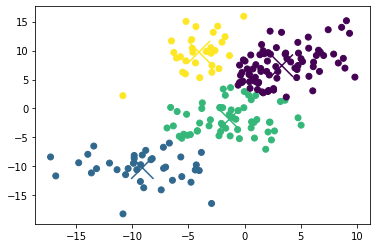

In [17]:
model = model_list[2]

plt.scatter(raw_data[0][:,0], raw_data[0][:,1], c=model.labels_)
plt.scatter(model.cluster_centers_[:,0], model.cluster_centers_[:,1], c=[0,1,2,3], marker='x', s=[500, 500,500,500])

Maybe the Elbow Method seems a bit too hand wavy to you. There are several other ways to pick the optimal number of clusters (Calinski-Harabasz Index, Davies-Bouldin Index, Dendrogram, Bayesian Information Criterion). One that is more systematic is the Silhouette Method. This method is a bit more complicated than the Elbow Method, but penalizes more complex models in the objective function it generates so there is a clear optimum that can be used to select the best $K$.

Each data point has a silhouette value quantifying how similar it is to its own cluster compared to other clusters (cohesion vs separation). This coefficient ranges between -1 and 1 where a value close to 1 indicates the object is well matched to its own cluster and poorly matched to neighboring clusters. If most objects have a high value, the clustering configuration is efficient. We'll use Euclidean distance to compute the silhouette coefficients.

For a data point in cluster $k$, $x_j \in S_k$, let
$$
a(j) = \frac{1}{|S_k|-1} \sum_{x_i \in S_k} ||x_i - x_j||^2
$$
be the mean distance between $j$ and all the other data points (and note $|S_k|$ is the number of points in cluster $k$). The smaller this value, the better the data point fits in with the rest of the cluster.

In addition, we will define the minimum dissimilarity of the point $x_j$ to another cluster $S_{{\rm min}(j)}$ where $S_{{\rm min}(j)} \neq S_k$:
$$
b(j) = {\rm min}_{l \neq k} \frac{1}{|S_l|} \sum_{x_i \in S_l} || x_i - x_j||^2,
$$
which is the smallest mean distance of $x_j$ to all points in another cluster of which $x_j$ is not a member. This closest cluster is often referred to as the neighboring cluster.

Now, we can define the silhouette value of the data point $x_j$ as
$$
s(j) = \frac{b(j) - a(j)}{{\rm max}(a(j), b(j))}
$$
if $|S_k|>1$, and $s(j) = 0$ otherwise. As mentioned, $-1 \leq s(j) \leq 1$.

The silhouette coefficient for all of the data is given by the average of the silhouette coefficients for all data points
$$
SC_K = \frac{1}{N} \sum_{j=1}^N s(j),
$$
and the number of clusters $K$ for which $SC_K$ is maximizes is considered the optimal choice of clusters under this metric.

There is of course a function in python to do all of this, contained in the sklearn.metrics class, which we just need to give the outputs of our model fits. The code for doing this is below. We will apply it to our already fit models applied to the synthetic blobs data.

Text(0, 0.5, 'silhouette score')

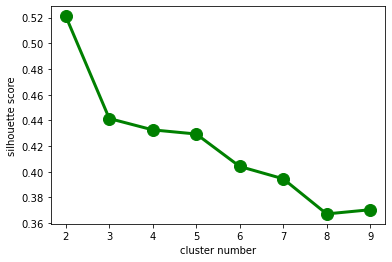

In [18]:
from sklearn.metrics import silhouette_score

silh_list = []

# loop through the fit models and compute the silhouette score and store in a list
# we use the Euclidean distance to compute distance between points and cluster
for j in range(0,8):
    model = model_list[j]
    silh_score = silhouette_score(raw_data[0], model.labels_, metric='euclidean')
    silh_list.append(silh_score)
    
plt.plot(range(2,10),silh_list,'go-', linewidth=3, markersize=12)
plt.xlabel("cluster number")
plt.ylabel("silhouette score")

Roughly consistent with our previous results, the best sihouette score occurs at two clusters. Just out of curiosity though, let's see what the cluster breakdown looks like when we try eight clusters (marked by the silhouette score as the worst cluster count).

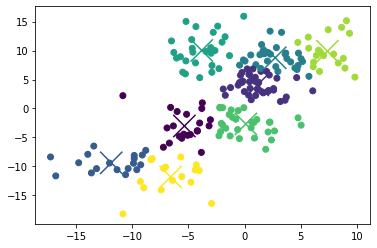

In [19]:
model = model_list[6]

plt.scatter(raw_data[0][:,0], raw_data[0][:,1], c=model.labels_)
plt.scatter(model.cluster_centers_[:,0], model.cluster_centers_[:,1], c=[0,1,2,3,4,5,6,7], marker='x', s=[500,500,500,500,500,500,500,500])